# Calibrating WOFOST 8.1 with SNOMIN

This notebook demonstrates gradient-based calibration of a crop model using
differentiable WOFOST 8.1 coupled to the SNOMIN soil nitrogen model.

We generate synthetic observations from a reference simulation and then use
gradient descent to estimate two crop parameters from the observations. This
illustrates how gradients can be propagated through the complete crop–soil
system, including crop growth, water balance and soil nitrogen dynamics.

## What is model calibration?

Crop models contain parameters that determine how the simulated crop responds
to weather, soil and management. Calibration is the process of estimating these
parameters from observations.

Here we use a simple synthetic example. We first run the model with known
parameter values to create reference observations. We then start from different
parameter values and use the difference between simulated and reference
observations as a loss function. PyTorch's automatic differentiation provides
the gradient of this loss with respect to the model parameters, which is used
by Adam to update them.

WOFOST simulates crop growth. SNOMIN describes the dynamics of soil organic
matter and mineral nitrogen. Together they make yield depend on the nitrogen
the soil can supply, not only on radiation and temperature.

```
Weather
   ↓
Water balance ─────┐
                   ↓
              WOFOST 8.1
                   ↑
SNOMIN → NAVAIL ──┘
                   ↓
             Crop growth
              ↓       ↓
             LAI     TWSO
```

`NAVAIL` is the mineral nitrogen the crop can take up. `LAI` is the leaf area
that results. `TWSO` is the weight of the storage organs, the simulated yield.
If water and nitrogen were assumed unlimited, changing a crop parameter would
only change the crop. Here the canopy, the soil water and the mineral nitrogen
all feed one another, so a gradient has to pass through that whole loop.

| Quantity | Used for optimization? | Shown as a model outcome? |
| --- | --- | --- |
| `LAI` | yes | yes |
| `NAVAIL` | no | yes |
| `TWSO` | no | yes |

Only `LAI` enters the loss. `NAVAIL` and `TWSO` are kept out of the optimizer
so that, afterwards, they show how a change in the crop parameters travels
through the coupled crop–soil system. The two parameters, and the values used
to generate the reference run, are introduced with the experiment below.

The notebook does not use a repository checkout. The next cells install
`diffwofost` from this branch, because WOFOST 8.1 is not in the released
package yet, and they download the weather and crop files. One season takes a few seconds on CPU. The calibration trajectory below is
stored from a previous 100-step run, so the notebook itself finishes in
seconds. Setting `RUN_CALIBRATION = True` repeats that search and takes
about fifteen minutes.
After the install, restart the kernel if the import cell still cannot see
`pcse`.


## 1. Setup

Install this branch into the kernel that is running the notebook. That install
brings in PCSE as well.


In [ ]:
%pip install --quiet "diffwofost @ git+https://github.com/WUR-AI/diffWOFOST.git@wofost81-snomin" matplotlib


In [ ]:
import urllib.request
from pathlib import Path

DATA = Path("snomin_calibration_data")
CROP_DIR = DATA / "crop"
CROP_DIR.mkdir(parents=True, exist_ok=True)
WEATHER = DATA / "weather_wageningen.xlsx"

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/ajwdewit/pcse_notebooks/master/data/meteo/weather_wageningen.xlsx",
    WEATHER,
)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/WUR-AI/NUE_PCSE-Gym/main/pcse_gym/envs/configs/crop/winterwheat.yaml",
    CROP_DIR / "winterwheat.yaml",
)
(CROP_DIR / "crops.yaml").write_text("available_crops:\n- winterwheat\n")
print(f"Weather: {WEATHER.resolve()}")
print(f"Crop file: {(CROP_DIR / 'winterwheat.yaml').resolve()}")


In [ ]:
import datetime as dt
import inspect
import tempfile
import textwrap
from pathlib import Path

import torch
import yaml
from pcse.input import ExcelWeatherDataProvider
from pcse.input import WOFOST81SiteDataProvider_SNOMIN
from pcse.input import YAMLAgroManagementReader
from pcse.input import YAMLCropDataProvider
from pcse.models import Wofost81_NWLP_MLWB_SNOMIN
from pcse.soil.soil_profile import SoilProfile

from diffwofost.physical_models.config import ComputeConfig
from diffwofost.physical_models.config import Configuration
from diffwofost.physical_models.crop.wofost81 import Wofost81
from diffwofost.physical_models.engine import Engine
from diffwofost.physical_models.parameter_providers import ParameterProvider
from diffwofost.physical_models.soil.soil_wrappers import SoilModuleWrapper_NWLP_MLWB_SNOMIN

ComputeConfig.set_dtype(torch.float64)
ComputeConfig.set_device("cpu")

SOWING = dt.date(2013, 10, 23)
SEASON_END = dt.date(2014, 7, 31)
CROP_NAME = "winterwheat"
VARIETY_NAME = "Arminda"
FERTILIZER_DATES = (SOWING, dt.date(2014, 3, 26), dt.date(2014, 4, 29))


## 2. The model and the experiment

The crop is winter wheat. For this synthetic experiment, the reference
simulation uses `TDWI` = 593 kg ha$^{-1}$ and `SPAN` = 35 days. `TDWI` is the
total dry weight at emergence, so it sets how large the canopy is at the start.
`SPAN` is the lifespan, in days, of leaves that grew at 35 °C, so it controls
how soon the canopy senesces.

We deliberately initialize the calibration at `TDWI` = 200 kg ha$^{-1}$ and
`SPAN` = 25 days to test whether optimization can recover the reference values.

The soil profile is the worked example in the PCSE `SoilProfile` docstring.
Site parameters use the defaults of `WOFOST81SiteDataProvider_SNOMIN`, plus the
four values that provider requires: initial available water `WAV`, atmospheric
`CO2`, and the initial ammonium and nitrate in each soil layer.

Weather is the Wageningen record shipped with the PCSE notebook that runs
WOFOST 8.1 and SNOMIN on SoilGrids. Sowing is 23 October 2013, and the
simulation stops at harvest on 31 July 2014. That window includes winter, the
spring sidedressings, and the summer in which the leaves senesce. The file
stores minimum and maximum temperature. Daily mean temperature is their
average, and daytime temperature `DTEMP` is the average of that mean and the
maximum, as in the WOFOST 8.1 tests.

Nitrogen is applied as three synthetic dressings, 180 kg N ha$^{-1}$ in total.
Each dressing is 60 kg N ha$^{-1}$, half ammonium and half nitrate, worked into
the top 10 cm, with no organic matter. The first goes on at sowing. The other
two are sidedressings on 26 March and 29 April 2014, during stem elongation.


In [5]:
def example_soil():
    lines = inspect.getdoc(SoilProfile).splitlines()
    start = next(i for i, line in enumerate(lines) if line.strip() == "SoilLayerTypes:")
    end = next(i for i, line in enumerate(lines) if line.strip().startswith("GroundWater:"))
    parsed = yaml.safe_load(textwrap.dedent("\n".join(lines[start : end + 1])))
    profile = parsed["SoilProfileDescription"]
    if "FSOMI" not in profile["SubSoilType"]:
        profile["SubSoilType"]["FSOMI"] = 0.0
    rootable = sum(layer["Thickness"] for layer in profile["SoilLayers"])
    return {"RDMSOL": float(rootable), "SoilProfileDescription": profile}


def weather_rows(start, end):
    provider = ExcelWeatherDataProvider(WEATHER)
    names = (
        "DAY", "LAT", "LON", "ELEV", "IRRAD", "TMIN", "TMAX",
        "VAP", "WIND", "RAIN", "E0", "ES0", "ET0",
    )
    rows = []
    day = start
    while day <= end:
        container = provider(day)
        item = {name: getattr(container, name) for name in names}
        item["TEMP"] = 0.5 * (item["TMIN"] + item["TMAX"])
        item["DTEMP"] = 0.5 * (item["TEMP"] + item["TMAX"])
        rows.append(item)
        day += dt.timedelta(days=1)
    return rows


def agro(start):
    harvest = start + dt.timedelta(days=300)
    dressings = tuple(zip(FERTILIZER_DATES, (60, 60, 60), strict=True))
    events = "\n".join(
        f"""        - {day.isoformat()}:
            amount: {amount}
            application_depth: 10
            cnratio: 0
            initial_age: 0
            f_NH4N: 0.5
            f_NO3N: 0.5
            f_orgmat: 0"""
        for day, amount in dressings
    )
    with tempfile.NamedTemporaryFile("w", suffix=".yaml", delete=False) as handle:
        path = Path(handle.name)
        handle.write(
            f"""
AgroManagement:
- {start.isoformat()}:
    CropCalendar:
        crop_name: {CROP_NAME}
        variety_name: {VARIETY_NAME}
        crop_start_date: {start.isoformat()}
        crop_start_type: sowing
        crop_end_date: {harvest.isoformat()}
        crop_end_type: harvest
        max_duration: 300
    TimedEvents:
      - event_signal: apply_n_snomin
        name: Synthetic nitrogen
        comment: amount is kg N/ha because the amendment is entirely mineral
        events_table:
{events}
    StateEvents: null
"""
        )
    try:
        return YAMLAgroManagementReader(str(path))
    finally:
        path.unlink(missing_ok=True)


rows = weather_rows(SOWING, SEASON_END)
crop = YAMLCropDataProvider(Wofost81_NWLP_MLWB_SNOMIN, fpath=CROP_DIR, force_reload=True)
soil = example_soil()
n_layers = len(soil["SoilProfileDescription"]["SoilLayers"])
site = WOFOST81SiteDataProvider_SNOMIN(
    WAV=20.0, CO2=360.0, NH4I=[10.0] * n_layers, NO3I=[1.0] * n_layers
)
campaign = agro(rows[0]["DAY"])
params = ParameterProvider(cropdata=crop, soildata=soil, sitedata=site)
params.set_active_crop(CROP_NAME, VARIETY_NAME, "sowing", "harvest")
true_span = float(params["SPAN"])
true_tdwi = float(params["TDWI"])
print(
    f"Reference SPAN = {true_span:.2f} days, TDWI = {true_tdwi:.1f} kg/ha. "
    f"Simulation = {rows[0]['DAY']} to {rows[-1]['DAY']}."
)


Reference SPAN = 35.00 days, TDWI = 593.0 kg/ha. Simulation = 2013-10-23 to 2014-07-31.


## 3. A first simulation

`NAVAIL` is the mineral nitrogen available to the crop, in kg N ha$^{-1}$. In
the SNOMIN configuration it changes every day. Mineralisation and fertilizer
add to it. Nitrification moves ammonium to nitrate. Immobilisation, crop
uptake, leaching and denitrification remove it, and the water content of the
soil changes how fast those processes run. The three dressings, 60 kg N ha$^{-1}$
each, are marked later on the `NAVAIL` figure.

`TWSO` is the weight of the storage organs, in kg ha$^{-1}$ of dry matter. At
harvest it is the simulated grain yield. It is not used to fit the parameters.
It is the agronomic endpoint of the season, shown with leaf area after the
calibration.

This cell runs the reference season, `TDWI` = 593 kg ha$^{-1}$ and `SPAN` = 35
days. Those curves are plotted once, next to the calibrated run.


In [6]:
config = Configuration(
    CROP=Wofost81,
    SOIL=SoilModuleWrapper_NWLP_MLWB_SNOMIN,
    OUTPUT_VARS=["LAI", "NAVAIL", "TWSO"],
)


def run(span, tdwi):
    """One SNOMIN season. Either argument may be a tensor that requires a gradient."""
    params.set_override("SPAN", span, check=False)
    params.set_override("TDWI", tdwi, check=False)
    model = Engine(config)
    model.setup(params, iter(rows), campaign)
    model.run_till(rows[-1]["DAY"])
    output = model.get_output()
    return {
        name: torch.stack([day[name].reshape(()) for day in output])
        for name in ("LAI", "NAVAIL", "TWSO")
    }


with torch.no_grad():
    observed = run(
        torch.tensor(true_span, dtype=torch.float64),
        torch.tensor(true_tdwi, dtype=torch.float64),
    )
print(
    f"Reference peak LAI = {observed['LAI'].max().item():.2f}. "
    f"Harvest TWSO = {observed['TWSO'][-1].item():.0f} kg/ha."
)


Reference peak LAI = 4.87. Harvest TWSO = 8832 kg/ha.


## 4. What is differentiable?

Calibration here is ordinary gradient descent on a PyTorch graph.

1. Treat `TDWI` and `SPAN` as tensors.
2. Run WOFOST 8.1 with SNOMIN for the whole season.
3. Compute a loss from the simulated leaf area and the reference leaf area.
4. Call `loss.backward()`. PyTorch walks the season in reverse and fills
   `.grad` on each parameter.
5. Read those gradients and update the parameters.
6. Repeat.

Most WOFOST equations are smooth arithmetic, so PyTorch can differentiate them
directly. A few processes are thresholds. Leaf cohorts die on a hard comparison
with `SPAN`: once the age of a cohort passes the lifespan, the forward pass
removes it exactly as WOFOST does. A straight-through estimator is used only
while `SPAN` itself requires a gradient. In the forward pass the hard threshold
is kept. In the backward pass a smooth step stands in for it, so the optimizer
receives a usable derivative instead of a zero from the dead branch of the
comparison.

The cell below takes one step of that procedure from the starting values,
`SPAN` 25 days and `TDWI` 200 kg ha$^{-1}$, and prints the two gradients. The
search itself is the longer loop in the next section. Logging a tensor with
`.detach().item()` reads out a number without cutting the graph that
`backward` still needs.


In [7]:
probe_span = torch.tensor(25.0, dtype=torch.float64, requires_grad=True)
probe_tdwi = torch.tensor(200.0, dtype=torch.float64, requires_grad=True)
probe = run(probe_span, probe_tdwi)
probe_loss = torch.mean(torch.abs(probe["LAI"] - observed["LAI"]))
probe_loss.backward()
print(
    f"Loss {probe_loss.detach().item():.4f}, "
    f"d(loss)/d(SPAN) {probe_span.grad.item():.4e}, "
    f"d(loss)/d(TDWI) {probe_tdwi.grad.item():.4e}"
)


Loss 1.0143, d(loss)/d(SPAN) -6.4281e-03, d(loss)/d(TDWI) -2.2029e-03


## 5. Gradient-based calibration

`LAI` is the calibration target because it is a time series. It records when
the canopy appears, how large it becomes, and when it senesces. The aim is not
to fit yield directly. It is to see whether the differentiable model can
recover the crop parameters that produced that growth.

Each parameter is kept inside a fixed range by storing it as a logit and
mapping that logit through a sigmoid. `SPAN` is limited to 10–60 days and
starts at 25. `TDWI` is limited to 50–1200 kg ha$^{-1}$ and starts at 200. The
loss is the mean absolute error of daily `LAI`.

The two parameters can stand in for each other. A longer leaf life raises late
leaf area in much the same way as a larger biomass at emergence raises early
leaf area, and both change the growth that follows. Early in the search,
`SPAN` can therefore walk past 35 while `TDWI` is still well below 593. When
the search is run live, the printed gradient is the derivative of the loss
with respect to the unbounded logit, not with respect to the parameter in days
or kg ha$^{-1}$.

The next cell loads a 100-step Adam run that was completed earlier, from the
same start and the same loss. The notebook plots that trajectory and then runs
the model once at the calibrated parameters. The cell after that repeats the
search only if you ask it to.


In [8]:
# Results from a previously completed 100-step Adam optimization.
precomputed = {
    "step": list(range(100)),
    "loss": [1.0143, 0.9808, 0.9437, 0.9095, 0.8725, 0.8331, 0.7980, 0.7584, 0.7188, 0.6791, 0.6373, 0.5945, 0.5529, 0.5124, 0.4712, 0.4282, 0.3867, 0.3507, 0.3299, 0.3168, 0.3066, 0.2981, 0.2935, 0.2887, 0.2848, 0.2818, 0.2803, 0.2827, 0.2875, 0.2929, 0.2996, 0.3078, 0.3147, 0.3214, 0.3276, 0.3306, 0.3350, 0.3370, 0.3383, 0.3406, 0.3456, 0.3450, 0.3412, 0.3311, 0.3205, 0.3141, 0.3062, 0.3006, 0.2931, 0.2875, 0.2803, 0.2735, 0.2675, 0.2619, 0.2561, 0.2503, 0.2435, 0.2380, 0.2321, 0.2260, 0.2205, 0.2145, 0.2091, 0.2034, 0.1991, 0.1933, 0.1890, 0.1817, 0.1702, 0.1599, 0.1506, 0.1420, 0.1333, 0.1270, 0.1196, 0.1129, 0.1079, 0.0995, 0.0874, 0.0755, 0.0662, 0.0552, 0.0501, 0.0412, 0.0361, 0.0321, 0.0264, 0.0254, 0.0192, 0.0056, 0.0042, 0.0069, 0.0085, 0.0112, 0.0151, 0.0198, 0.0258, 0.0266, 0.0253, 0.0244],
    "SPAN": [25.53, 26.07, 26.62, 27.19, 27.76, 28.34, 28.93, 29.54, 30.15, 30.77, 31.40, 32.05, 32.70, 33.36, 34.02, 34.69, 35.36, 36.04, 36.72, 37.40, 38.07, 38.74, 39.40, 40.04, 40.67, 41.30, 41.89, 42.45, 42.97, 43.43, 43.85, 44.20, 44.51, 44.77, 44.99, 45.17, 45.32, 45.44, 45.53, 45.52, 45.42, 45.25, 45.01, 44.71, 44.42, 44.14, 43.87, 43.60, 43.35, 43.11, 42.87, 42.64, 42.42, 42.21, 42.00, 41.80, 41.60, 41.42, 41.24, 41.06, 40.90, 40.74, 40.58, 40.44, 40.30, 40.16, 39.92, 39.60, 39.30, 39.03, 38.78, 38.55, 38.34, 38.16, 37.99, 37.84, 37.59, 37.25, 36.95, 36.69, 36.45, 36.25, 36.08, 35.93, 35.80, 35.70, 35.62, 35.43, 35.16, 34.94, 34.85, 34.88, 34.82, 34.68, 34.52, 34.36, 34.32, 34.38, 34.43, 34.45],
    "TDWI": [206.6, 213.5, 220.7, 228.1, 235.8, 243.8, 252.1, 260.6, 269.5, 278.7, 288.2, 298.0, 308.2, 318.7, 329.5, 340.7, 352.2, 364.0, 376.1, 388.4, 401.0, 413.8, 426.7, 439.8, 452.9, 466.2, 479.3, 492.1, 504.4, 516.3, 527.5, 538.0, 547.7, 556.8, 565.2, 573.1, 580.5, 587.4, 593.9, 597.6, 599.0, 598.3, 595.8, 591.6, 588.1, 585.0, 582.5, 580.4, 578.8, 577.5, 576.6, 576.0, 575.7, 575.7, 576.0, 576.5, 577.3, 578.3, 579.5, 581.0, 582.6, 584.4, 586.4, 588.6, 590.9, 593.5, 593.6, 591.6, 590.2, 589.3, 589.0, 589.1, 589.7, 590.6, 592.0, 593.7, 593.1, 590.4, 588.6, 587.4, 586.9, 586.9, 587.5, 588.6, 590.2, 592.2, 594.6, 594.7, 592.7, 591.8, 592.9, 595.9, 596.9, 596.2, 594.6, 592.5, 592.6, 594.6, 595.8, 596.3],
}
loss_history = precomputed["loss"]
span_history = precomputed["SPAN"]
tdwi_history = precomputed["TDWI"]
SPAN_INIT, TDWI_INIT = 25.0, 200.0
calibrated_span = 34.45
calibrated_tdwi = 596.3
print(
    f"Stored trajectory: {len(loss_history)} steps. "
    f"Final loss {loss_history[-1]:.4f}, "
    f"SPAN {calibrated_span:.2f}, TDWI {calibrated_tdwi:.1f}."
)


Stored trajectory: 100 steps. Final loss 0.0244, SPAN 34.45, TDWI 596.3.


## Optional: run the full calibration

Set `RUN_CALIBRATION` to `True` to repeat the 100-step search from scratch.
That overwrites the stored trajectory. Leave it `False` to keep the
demonstration on the stored results. A hundred steps takes about fifteen
minutes.


In [9]:
# Set to True to reproduce the optimization from scratch.
RUN_CALIBRATION = False

if RUN_CALIBRATION:
    class BoundedParameter(torch.nn.Module):
        def __init__(self, low, high, init_value):
            super().__init__()
            self.low = low
            self.high = high
            init_norm = (init_value - low) / (high - low)
            self.raw = torch.nn.Parameter(
                torch.logit(torch.tensor(init_norm, dtype=torch.float64), eps=1e-6)
            )

        def forward(self):
            return self.low + (self.high - self.low) * torch.sigmoid(self.raw)

    span = BoundedParameter(10.0, 60.0, SPAN_INIT)
    tdwi = BoundedParameter(50.0, 1200.0, TDWI_INIT)
    optimizer = torch.optim.Adam(
        list(span.parameters()) + list(tdwi.parameters()), lr=0.05
    )
    loss_history, span_history, tdwi_history = [], [], []
    for step in range(100):
        optimizer.zero_grad()
        simulated = run(span(), tdwi())
        loss = torch.mean(torch.abs(simulated["LAI"] - observed["LAI"]))
        loss.backward()
        span_gradient = span.raw.grad
        tdwi_gradient = tdwi.raw.grad
        optimizer.step()
        loss_history.append(loss.detach().item())
        span_history.append(span().detach().item())
        tdwi_history.append(tdwi().detach().item())
        print(
            f"Step {step}, loss {loss_history[-1]:.4f}, "
            f"SPAN {span_history[-1]:.2f}, TDWI {tdwi_history[-1]:.1f}, "
            f"grads {span_gradient.item():.4e} {tdwi_gradient.item():.4e}"
        )
    calibrated_span = span_history[-1]
    calibrated_tdwi = tdwi_history[-1]
    print(
        f"Reference SPAN {true_span:.2f}, TDWI {true_tdwi:.1f}. "
        f"Calibrated SPAN {calibrated_span:.2f}, TDWI {calibrated_tdwi:.1f}."
    )
else:
    print(
        "Using the stored 100-step trajectory. "
        f"Calibrated SPAN = {calibrated_span:.2f}, TDWI = {calibrated_tdwi:.1f}."
    )


Using the stored 100-step trajectory. Calibrated SPAN = 34.45, TDWI = 596.3.


## 6. Optimization results

The upper panel is the leaf-area error at each Adam step. The lower panel
shows the two parameters, with dotted lines at the reference values. Because
the parameters trade off, the error can rise again for a while after `SPAN`
has already passed 35, and then fall once `TDWI` catches up. With about a
hundred steps both parameters arrive close to the reference values. Unless
`RUN_CALIBRATION` was set, this is the stored trajectory.


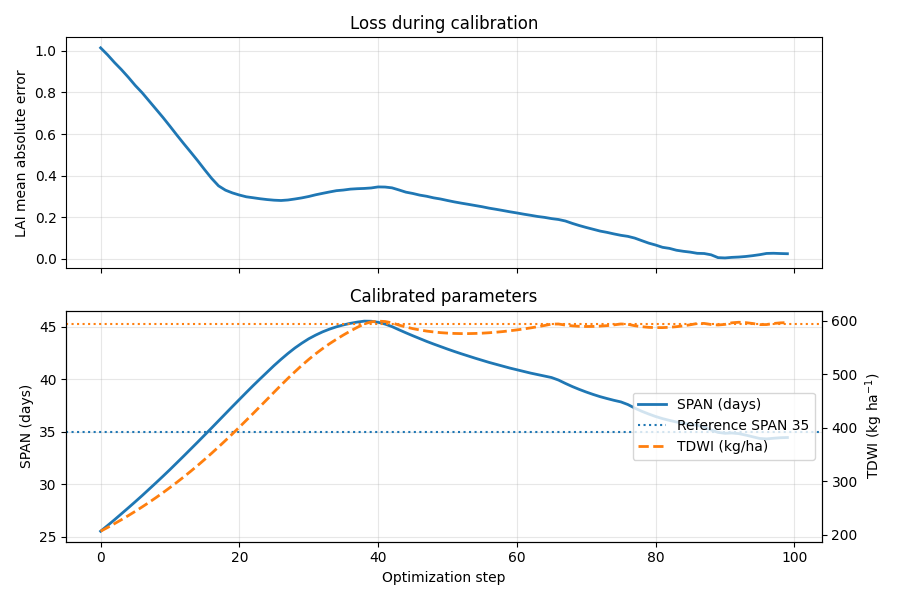

Calibrated: SPAN = 34.45, TDWI = 596.3
Reference:  SPAN = 35.00, TDWI = 593.0


In [8]:
import matplotlib.pyplot as plt

steps = range(len(loss_history))
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(steps, loss_history, linewidth=2)
axes[0].set_ylabel("LAI mean absolute error")
axes[0].set_title("Loss during calibration")
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, span_history, label="SPAN (days)", linewidth=2)
axes[1].axhline(true_span, color="C0", linestyle=":", label=f"Reference SPAN {true_span:.0f}")
tdwi_axis = axes[1].twinx()
tdwi_axis.plot(steps, tdwi_history, color="C1", linestyle="--", label="TDWI (kg/ha)", linewidth=2)
tdwi_axis.axhline(true_tdwi, color="C1", linestyle=":")
axes[1].set_xlabel("Optimization step")
axes[1].set_ylabel("SPAN (days)")
tdwi_axis.set_ylabel("TDWI (kg ha$^{-1}$)")
axes[1].set_title("Calibrated parameters")
handles, labels = axes[1].get_legend_handles_labels()
tdwi_handles, tdwi_labels = tdwi_axis.get_legend_handles_labels()
axes[1].legend(handles + tdwi_handles, labels + tdwi_labels, loc="center right")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Calibrated: SPAN = {calibrated_span:.2f}, TDWI = {calibrated_tdwi:.1f}")
print(f"Reference:  SPAN = {true_span:.2f}, TDWI = {true_tdwi:.1f}")


## 7. From one observation to the whole system

The calibration uses a single observable. What it changes is the coupled model.

```
Observations
    LAI
      ↓
Calibration
    TDWI, SPAN
      ↓
Coupled model
    water balance + SNOMIN + crop growth
      ↓
Consequences
    NAVAIL → LAI → TWSO
```

`TDWI` and `SPAN` are crop parameters, but they do not act on leaf area alone.
A different canopy takes up a different amount of nitrogen, so `NAVAIL` changes.
A different canopy also assimilates differently, so the storage organs fill
differently and `TWSO` changes. The three figures below separate those roles.
Leaf area is the calibration target. Soil nitrogen is the SNOMIN state, with a
line at each of the three fertilizer applications. Storage-organ weight is the
agronomic outcome, and the numbers at the right-hand side are the yield at
harvest.


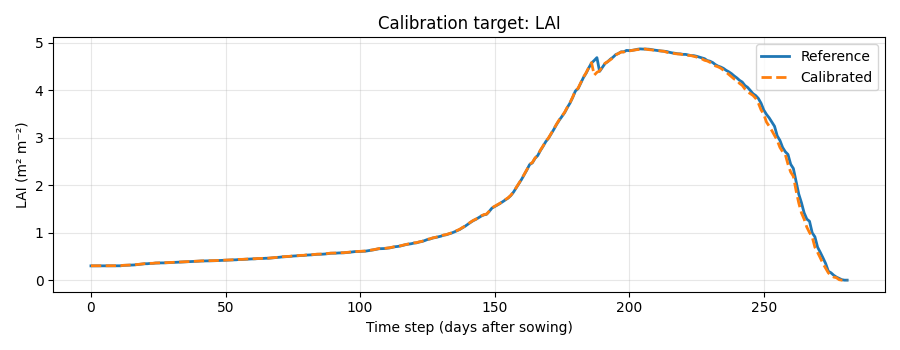

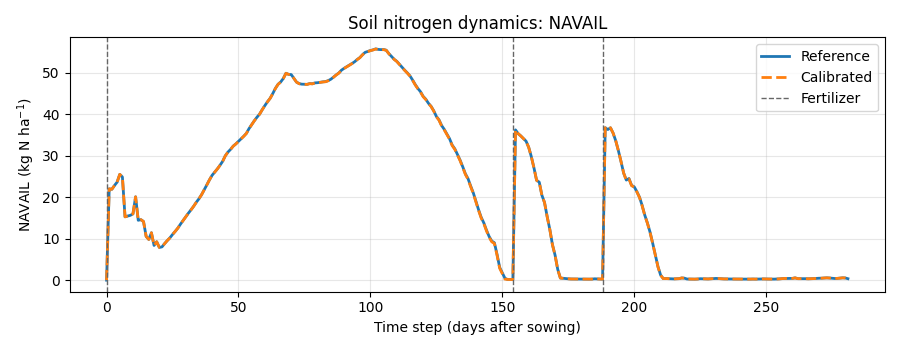

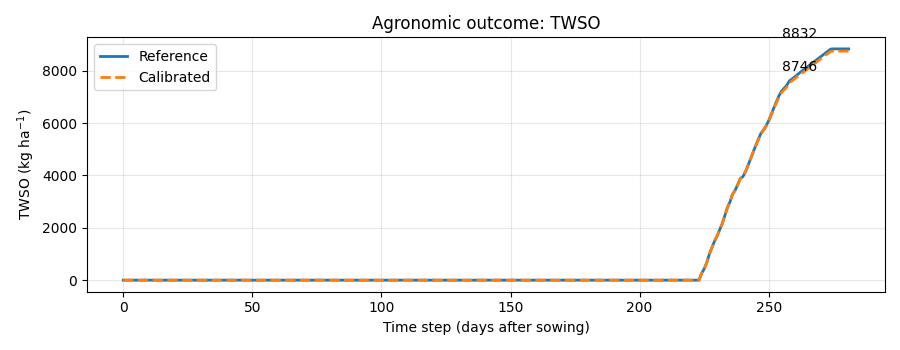

Harvest TWSO: reference 8832 kg/ha, calibrated 8746 kg/ha.


In [10]:
with torch.no_grad():
    optimized = run(
        torch.tensor(calibrated_span, dtype=torch.float64),
        torch.tensor(calibrated_tdwi, dtype=torch.float64),
    )

import matplotlib.pyplot as plt

days = range(len(observed["LAI"]))
fertilizer_days = [(day - SOWING).days for day in FERTILIZER_DATES]


def as_numpy(values):
    return values.detach().numpy() if torch.is_tensor(values) else values


def reference_and_calibrated(key, ylabel, title):
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(days, as_numpy(observed[key]), label="Reference", linewidth=2)
    ax.plot(days, as_numpy(optimized[key]), label="Calibrated", linewidth=2, linestyle="--")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time step (days after sowing)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return fig, ax


fig, ax = reference_and_calibrated("LAI", "LAI (m² m⁻²)", "Calibration target: LAI")
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = reference_and_calibrated(
    "NAVAIL", "NAVAIL (kg N ha$^{-1}$)", "Soil nitrogen dynamics: NAVAIL"
)
for index, day in enumerate(fertilizer_days):
    ax.axvline(
        day,
        color="0.4",
        linestyle="--",
        linewidth=1,
        label="Fertilizer" if index == 0 else None,
    )
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = reference_and_calibrated(
    "TWSO", "TWSO (kg ha$^{-1}$)", "Agronomic outcome: TWSO"
)
reference_yield = float(as_numpy(observed["TWSO"])[-1])
calibrated_yield = float(as_numpy(optimized["TWSO"])[-1])
last = len(observed["LAI"]) - 1
ax.annotate(
    f"{reference_yield:.0f}",
    xy=(last, reference_yield),
    xytext=(-48, 8),
    textcoords="offset points",
)
ax.annotate(
    f"{calibrated_yield:.0f}",
    xy=(last, calibrated_yield),
    xytext=(-48, -14),
    textcoords="offset points",
)
ax.legend()
fig.tight_layout()
plt.show()
print(
    f"Harvest TWSO: reference {reference_yield:.0f} kg/ha, "
    f"calibrated {calibrated_yield:.0f} kg/ha."
)


## 8. Interpretation

The stored search recovers both parameters, but not along a straight path.
`SPAN` and `TDWI` are only weakly separate in a leaf-area series: a longer leaf
life can imitate a larger biomass at emergence for part of the season. That is
why `SPAN` overshoots 35 while `TDWI` is still climbing, and why the loss is
not monotone. A hundred steps is enough for both to settle next to the
reference values, 35 days and 593 kg ha$^{-1}$.

The important point is what those parameters do after they have been found. The
loss saw only `LAI`. Because `TDWI` and `SPAN` sit inside the coupled crop–soil
model, the same values also determine how much mineral nitrogen remains in the
soil and how much grain the crop forms. `NAVAIL` moving with the fertilizer
dates shows that SNOMIN is part of the simulation. `TWSO` shows that fitting
the canopy was enough to restore the yield.
